In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../Datasets/CoffeeShopSales-cleaned.csv")
df

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,total_amount,week,weekday,transaction_hour
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.00,2022-12-26/2023-01-01,Sunday,7
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.20,2022-12-26/2023-01-01,Sunday,7
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.00,2022-12-26/2023-01-01,Sunday,7
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.00,2022-12-26/2023-01-01,Sunday,7
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.20,2022-12-26/2023-01-01,Sunday,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149111,149452,2023-06-30,20:18:41,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg,5.00,2023-06-26/2023-07-02,Friday,20
149112,149453,2023-06-30,20:25:10,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg,6.00,2023-06-26/2023-07-02,Friday,20
149113,149454,2023-06-30,20:31:34,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg,3.00,2023-06-26/2023-07-02,Friday,20
149114,149455,2023-06-30,20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino,3.75,2023-06-26/2023-07-02,Friday,20


In [3]:
df = df.drop(['transaction_id','transaction_time','week'], axis=1)

In [4]:
df

,transaction_date,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,total_amount,weekday,transaction_hour
0,2023-01-01,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.00,Sunday,7
1,2023-01-01,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.20,Sunday,7
2,2023-01-01,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.00,Sunday,7
3,2023-01-01,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.00,Sunday,7
4,2023-01-01,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.20,Sunday,7
...,...,...,...,...,...,...,...,...,...,...,...,...
149111,2023-06-30,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg,5.00,Friday,20
149112,2023-06-30,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg,6.00,Friday,20
149113,2023-06-30,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg,3.00,Friday,20
149114,2023-06-30,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino,3.75,Friday,20


In [5]:
df.isnull().sum()

transaction_date    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
total_amount        0
weekday             0
transaction_hour    0
dtype: int64

In [6]:
df.dtypes

transaction_date     object
transaction_qty       int64
store_id              int64
store_location       object
product_id            int64
unit_price          float64
product_category     object
product_type         object
product_detail       object
total_amount        float64
weekday              object
transaction_hour      int64
dtype: object

In [7]:
df.transaction_date = pd.to_datetime(df.transaction_date)

In [8]:
df.dtypes

transaction_date    datetime64[ns]
transaction_qty              int64
store_id                     int64
store_location              object
product_id                   int64
unit_price                 float64
product_category            object
product_type                object
product_detail              object
total_amount               float64
weekday                     object
transaction_hour             int64
dtype: object

In [9]:
df.columns

Index(['transaction_date', 'transaction_qty', 'store_id', 'store_location',
       'product_id', 'unit_price', 'product_category', 'product_type',
       'product_detail', 'total_amount', 'weekday', 'transaction_hour'],
      dtype='object')

In [10]:
df['month'] = df.transaction_date.dt.month

In [11]:
df

,transaction_date,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,total_amount,weekday,transaction_hour,month
0,2023-01-01,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.00,Sunday,7,1
1,2023-01-01,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.20,Sunday,7,1
2,2023-01-01,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.00,Sunday,7,1
3,2023-01-01,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.00,Sunday,7,1
4,2023-01-01,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.20,Sunday,7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149111,2023-06-30,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg,5.00,Friday,20,6
149112,2023-06-30,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg,6.00,Friday,20,6
149113,2023-06-30,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg,3.00,Friday,20,6
149114,2023-06-30,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino,3.75,Friday,20,6


In [12]:
df.describe()

,transaction_date,transaction_qty,store_id,product_id,unit_price,total_amount,transaction_hour,month
count,149116,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000
mean,2023-04-15 11:50:32.173609984,1.438276,5.342063,47.918607,3.382219,4.686367,11.735790,3.988881
min,2023-01-01 00:00:00,1.000000,3.000000,1.000000,0.800000,0.800000,6.000000,1.000000
25%,2023-03-06 00:00:00,1.000000,3.000000,33.000000,2.500000,3.000000,9.000000,3.000000
50%,2023-04-24 00:00:00,1.000000,5.000000,47.000000,3.000000,3.750000,11.000000,4.000000
75%,2023-05-30 00:00:00,2.000000,8.000000,60.000000,3.750000,6.000000,15.000000,5.000000
max,2023-06-30 00:00:00,8.000000,8.000000,87.000000,45.000000,360.000000,20.000000,6.000000
std,NaN,0.542509,2.074241,17.930020,2.658723,4.227099,3.764662,1.673091


In [13]:
df.transaction_qty.corr(df.total_amount)

np.float64(0.3562308526230814)

In [14]:
df.corr(numeric_only=True)

,transaction_qty,store_id,product_id,unit_price,total_amount,transaction_hour,month
transaction_qty,1.000000,-0.000794,-0.175255,-0.123546,0.356231,-0.006310,0.002849
store_id,-0.000794,1.000000,0.025727,0.001891,0.004595,-0.075813,-0.000900
product_id,-0.175255,0.025727,1.000000,-0.140423,-0.167461,-0.031644,-0.002370
unit_price,-0.123546,0.001891,-0.140423,1.000000,0.685550,-0.018435,-0.002004
total_amount,0.356231,0.004595,-0.167461,0.685550,1.000000,-0.013783,0.001243
transaction_hour,-0.006310,-0.075813,-0.031644,-0.018435,-0.013783,1.000000,0.003505
month,0.002849,-0.000900,-0.002370,-0.002004,0.001243,0.003505,1.000000


In [15]:
df.groupby('store_location')['total_amount'].sum().sort_values(ascending=False)

store_location
Hell's Kitchen     236511.17
Astoria            232243.91
Lower Manhattan    230057.25
Name: total_amount, dtype: float64

In [16]:
df.groupby('month')['total_amount'].sum().sort_values(ascending=False)

month
6    166485.88
5    156727.76
4    118941.08
3     98834.68
1     81677.74
2     76145.19
Name: total_amount, dtype: float64

In [17]:
df.groupby('product_category')['total_amount'].sum().sort_values(ascending=False)

product_category
Coffee                269952.45
Tea                   196405.95
Bakery                 82315.64
Drinking Chocolate     72416.00
Coffee beans           40085.25
Branded                13607.00
Loose Tea              11213.60
Flavours                8408.80
Packaged Chocolate      4407.64
Name: total_amount, dtype: float64

In [18]:
df.groupby('product_category')['total_amount'].sum().sort_values(ascending=False).head(5)

product_category
Coffee                269952.45
Tea                   196405.95
Bakery                 82315.64
Drinking Chocolate     72416.00
Coffee beans           40085.25
Name: total_amount, dtype: float64

In [19]:
df.groupby('product_type')['transaction_qty'].sum().sort_values(ascending=False).head(10)

product_type
Brewed Chai tea          26250
Gourmet brewed coffee    25973
Barista Espresso         24943
Brewed Black tea         17462
Hot chocolate            17457
Brewed herbal tea        17328
Organic brewed coffee    13012
Drip coffee              12891
Premium brewed coffee    12431
Scone                    10465
Name: transaction_qty, dtype: int64

In [20]:
df.groupby('product_type')['transaction_qty'].sum().sort_values().head(10)

product_type
Green beans           134
Green tea             159
House blend Beans     183
Clothing              221
Organic Chocolate     221
Drinking Chocolate    266
Black tea             303
Herbal tea            305
Espresso Beans        319
Gourmet Beans         366
Name: transaction_qty, dtype: int64

In [21]:
df.groupby('weekday')['total_amount'].mean().sort_values(ascending=False)

weekday
Saturday     4.724255
Wednesday    4.707346
Monday       4.697929
Tuesday      4.690875
Friday       4.671352
Sunday       4.661088
Thursday     4.653541
Name: total_amount, dtype: float64

In [22]:
pd.pivot_table(df,values='total_amount',index='product_category',columns='store_location',aggfunc='sum')

store_location,Astoria,Hell's Kitchen,Lower Manhattan
product_category,,,
Bakery,26599.75,27386.95,28328.94
Branded,5457.00,1942.00,6208.00
Coffee,89744.30,91222.65,88985.50
Coffee beans,10219.20,18635.10,11230.95
Drinking Chocolate,26335.25,23586.25,22494.50
Flavours,1764.80,2876.80,3767.20
Loose Tea,3194.00,4461.35,3558.25
Packaged Chocolate,1089.71,1698.77,1619.16
Tea,67839.90,64701.30,63864.75


In [23]:
pd.pivot_table(df,values='total_amount',index='weekday',columns='store_location',aggfunc='sum')

store_location,Astoria,Hell's Kitchen,Lower Manhattan
weekday,,,
Friday,33472.75,34743.18,33157.07
Monday,33928.29,33389.51,34359.48
Saturday,31845.93,32599.23,32449.32
Sunday,32795.18,33685.63,31849.50
Thursday,34140.37,33468.06,33159.35
Tuesday,31816.76,34846.47,32792.71
Wednesday,34244.63,33779.09,32289.82


In [24]:
pd.pivot_table(df,values='transaction_qty',index='product_type',columns='product_category',aggfunc='sum',fill_value=0)

product_category,Bakery,Branded,Coffee,Coffee beans,Drinking Chocolate,Flavours,Loose Tea,Packaged Chocolate,Tea
product_type,,,,,,,,,
Barista Espresso,0,0,24943,0,0,0,0,0,0
Biscotti,5788,0,0,0,0,0,0,0,0
Black tea,0,0,0,0,0,0,303,0,0
Brewed Black tea,0,0,0,0,0,0,0,0,17462
Brewed Chai tea,0,0,0,0,0,0,0,0,26250
Brewed Green tea,0,0,0,0,0,0,0,0,8697
Brewed herbal tea,0,0,0,0,0,0,0,0,17328
Chai tea,0,0,0,0,0,0,443,0,0
Clothing,0,221,0,0,0,0,0,0,0


In [25]:
pd.pivot_table(df,values='transaction_qty',index='month',columns='product_category',aggfunc='sum')

product_category,Bakery,Branded,Coffee,Coffee beans,Drinking Chocolate,Flavours,Loose Tea,Packaged Chocolate,Tea
month,,,,,,,,,
1,2690,100,10355,234,2015,1218,141,57,8060
2,2559,74,9689,195,1964,1163,137,51,7718
3,3358,104,12604,251,2475,1465,178,65,9906
4,3951,142,15210,310,2952,1773,197,95,11839
5,5225,161,19948,407,3930,2382,259,108,15813
6,5431,195,21444,431,4121,2510,298,111,16401


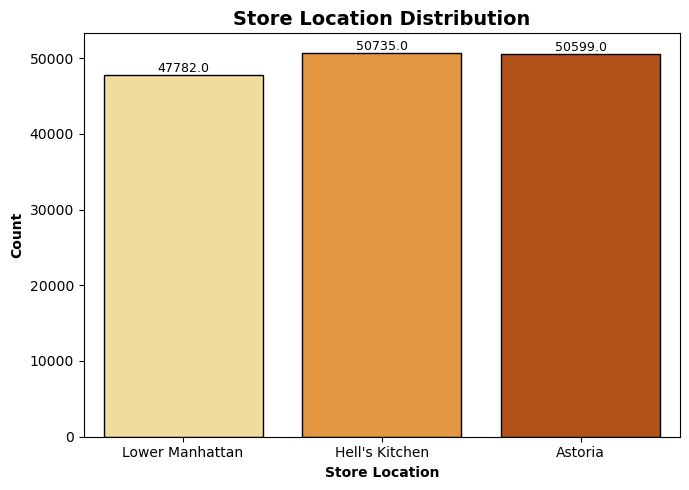

In [42]:
plt.figure(figsize=(7,5))

ax = sb.countplot(x='store_location',data=df,palette='YlOrBr',edgecolor='black')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height()}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("Store Location Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Store Location",fontsize=10, fontweight='bold')
plt.ylabel("Count",fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

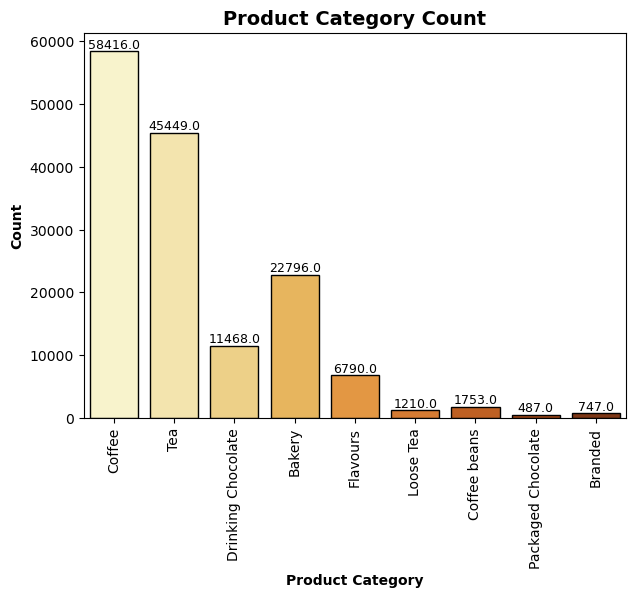

In [43]:
plt.figure(figsize=(7,5))
ax = sb.countplot(x='product_category',data=df,palette='YlOrBr',edgecolor='black')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height()}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("Product Category Count", fontsize=14, fontweight='bold')
plt.xlabel("Product Category", fontsize=10, fontweight='bold')
plt.ylabel("Count",fontsize=10, fontweight='bold')
plt.xticks(rotation = 90)

plt.show()

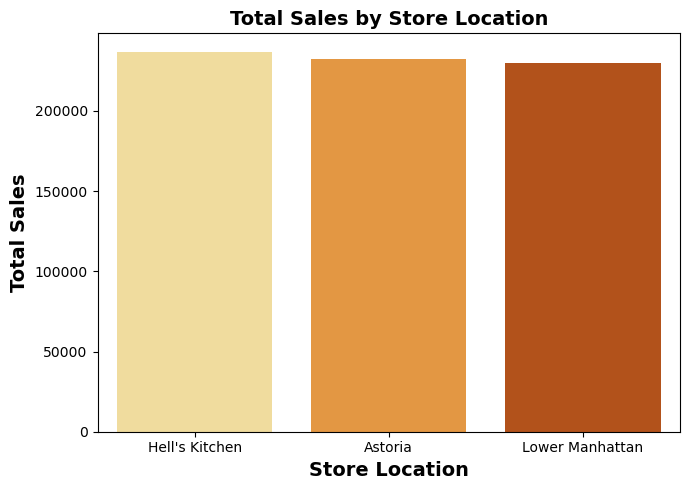

In [44]:
plt.figure(figsize=(7,5))

data = df.groupby('store_location')['total_amount'].sum().sort_values(ascending=False)

sb.barplot(x=data.index,y=data.values,palette='YlOrBr')

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("Total Sales by Store Location", fontsize=14, fontweight='bold')
plt.xlabel("Store Location",fontsize=14, fontweight='bold')
plt.ylabel("Total Sales",fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

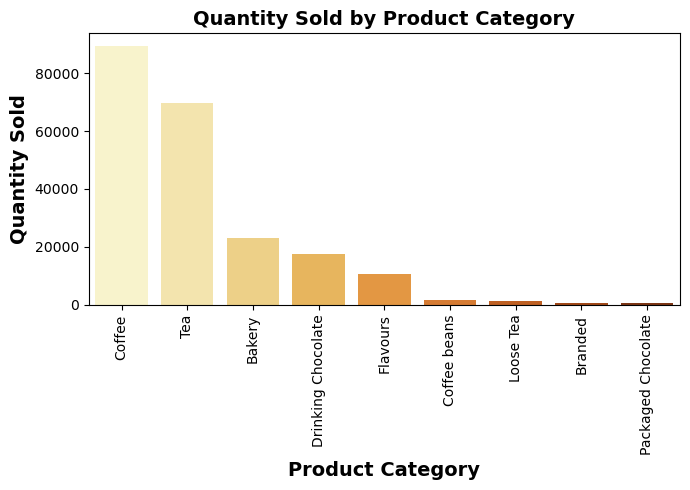

In [45]:
plt.figure(figsize=(7,5))

data = df.groupby('product_category')['transaction_qty'].sum().sort_values(ascending=False)

sb.barplot(x=data.index,y=data.values,palette='YlOrBr')

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("Quantity Sold by Product Category", fontsize=14, fontweight='bold')
plt.xlabel("Product Category", fontsize=14, fontweight='bold')
plt.ylabel("Quantity Sold", fontsize=14, fontweight='bold')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

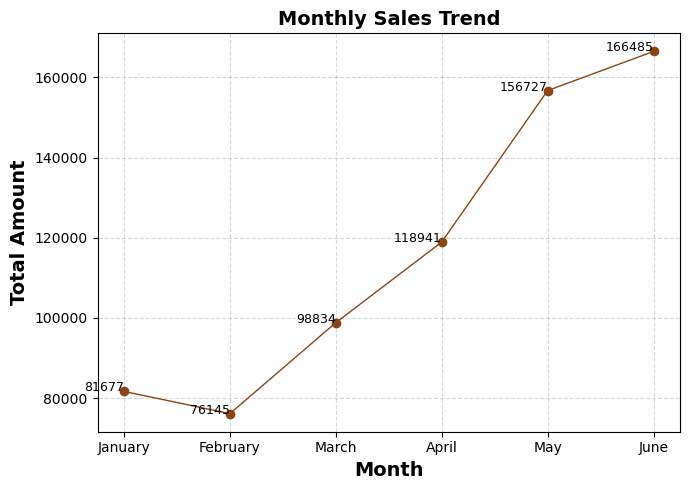

In [46]:
plt.figure(figsize=(7,5))

df.transaction_date = pd.to_datetime(df.transaction_date)
df.month = df.transaction_date.dt.month_name()
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
data = df.groupby('month')['total_amount'].sum().reindex(month_order)

plt.plot(data.index,data.values,marker='o',linewidth=1,color='#8B4513')

for x, y in zip(data.index, data.values):
    if pd.notna(y):
        plt.text(x, y, f'{int(y)}', ha='right', fontsize=9)

plt.title("Monthly Sales Trend", fontsize=14, fontweight='bold')
plt.xlabel("Month", fontsize=14, fontweight='bold')
plt.ylabel("Total Amount", fontsize=14, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

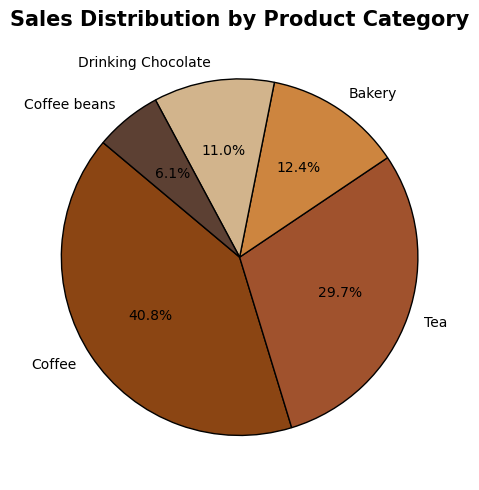

In [48]:
plt.figure(figsize=(5,5))

data = df.groupby('product_category')['total_amount'].sum().sort_values(ascending=False)

top5 = data.head(5)

brown_colors = ['#8B4513','#A0522D','#CD853F','#D2B48C','#5C4033','#C19A6B']

plt.pie(top5,labels=top5.index,autopct='%1.1f%%',startangle=140,colors=brown_colors,wedgeprops={'edgecolor':'black'},textprops={'fontsize':10})

plt.title("Sales Distribution by Product Category",fontsize=15,fontweight='bold')

plt.tight_layout()
plt.show()

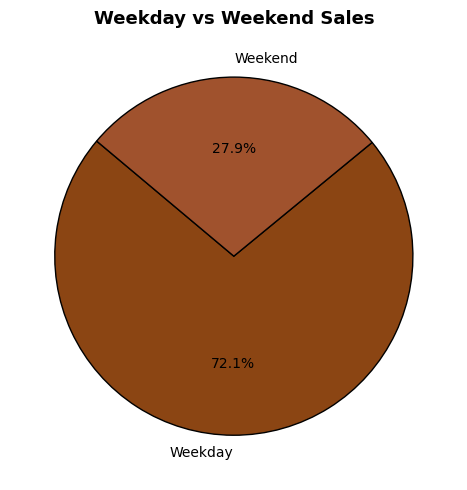

In [70]:
df.day_type = df.weekday.apply(lambda x: 'Weekend' if x in ['Saturday','Sunday'] else 'Weekday')
plt.figure(figsize=(5,5))

brown_colors = ['#8B4513', '#A0522D', '#CD853F', '#D2B48C', '#5C4033']

data = df.groupby('day_type')['total_amount'].sum()

plt.pie(data,labels=data.index,autopct='%1.1f%%',colors=brown_colors,startangle=140,wedgeprops={'edgecolor':'black'})

plt.title("Weekday vs Weekend Sales", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show() 

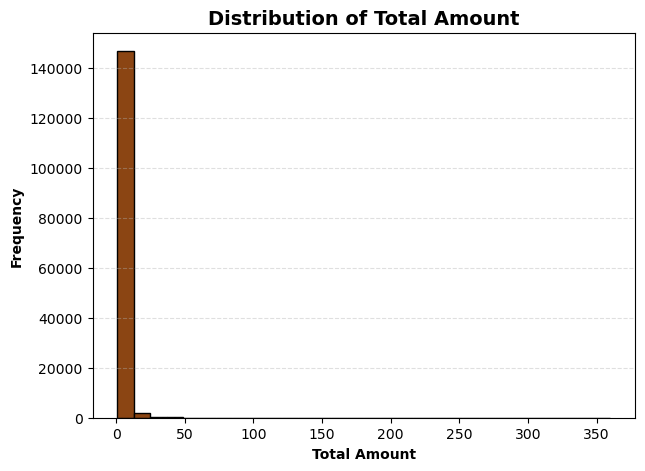

In [49]:
plt.figure(figsize=(7,5))

plt.hist(df.total_amount,bins=30,color='#8B4513',edgecolor='black')

plt.title("Distribution of Total Amount",fontsize=14,fontweight='bold')

plt.xlabel("Total Amount",fontsize=10,fontweight='bold')

plt.ylabel("Frequency",fontsize=10,fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

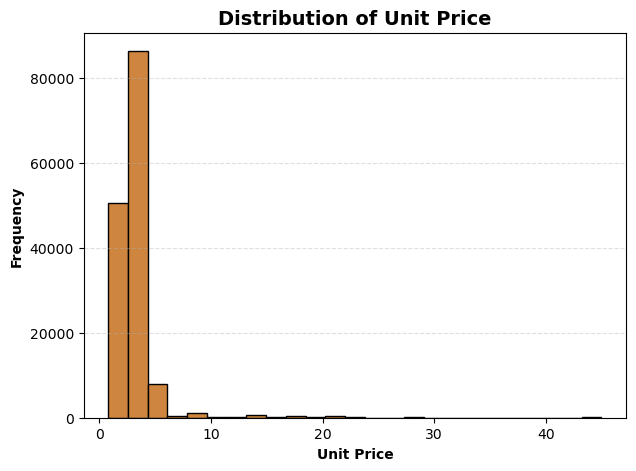

In [50]:
plt.figure(figsize=(7,5))

plt.hist(df.unit_price,bins=25,color='#CD853F',edgecolor='black')

plt.title("Distribution of Unit Price",fontsize=14,fontweight='bold')

plt.xlabel("Unit Price",fontsize=10,fontweight='bold')

plt.ylabel("Frequency",fontsize=10,fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

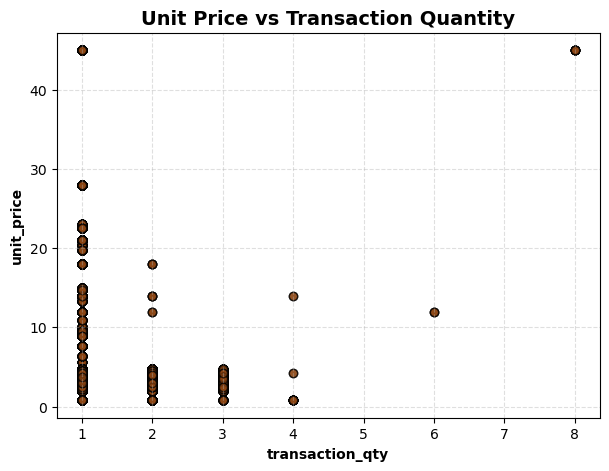

In [51]:
plt.figure(figsize=(7,5))

plt.scatter(df.transaction_qty,df.unit_price,color='#8B4513',edgecolors='black',alpha=0.7)

plt.xlabel("transaction_qty",fontsize=10,fontweight='bold')

plt.ylabel("unit_price",fontsize=10,fontweight='bold')
           
plt.title("Unit Price vs Transaction Quantity",fontsize=14,fontweight='bold')
           
plt.grid(linestyle='--', alpha=0.4)

plt.show()

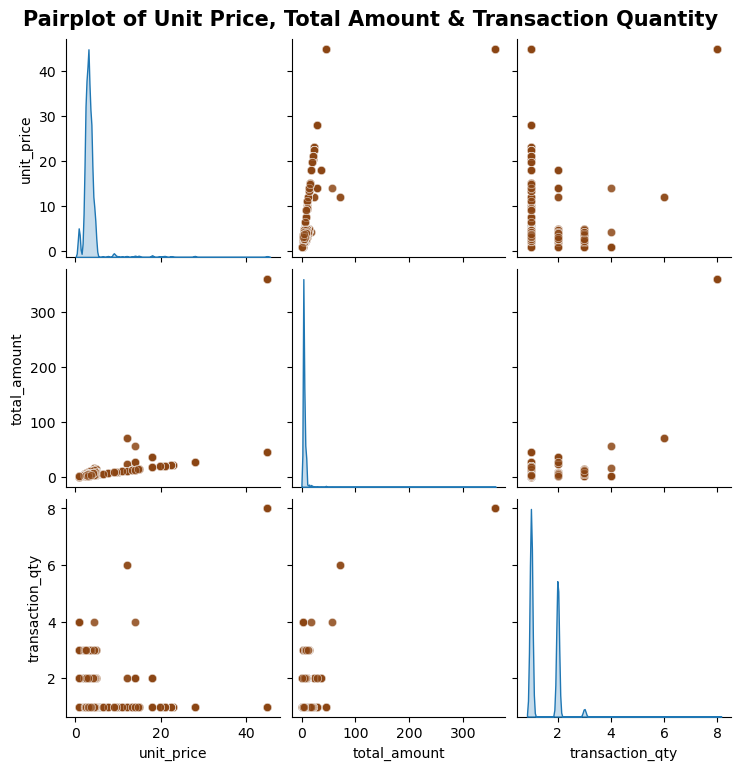

In [64]:
cols = ['unit_price', 'total_amount', 'transaction_qty']

sb.pairplot(df[cols],diag_kind='kde',plot_kws={'color':'#8B4513','alpha':0.6})

plt.suptitle("Pairplot of Unit Price, Total Amount & Transaction Quantity",y=1.02,fontsize=15,fontweight='bold')

plt.show()

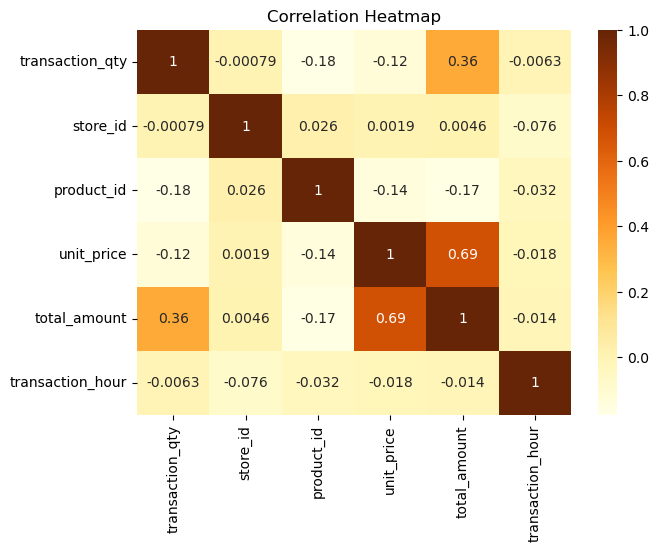

In [41]:
plt.figure(figsize=(7,5))
sb.heatmap(df.corr(numeric_only=True), annot=True, cmap='YlOrBr')
plt.title("Correlation Heatmap")
plt.show()